# Предсказание продаж в магазине

## Датасет

<b>1. Store ID</b>: (Index) ID of the particular store.<br>
<b>2. Store_Area</b>: Physical Area of the store in yard square.<br>
<b>3. Items_Available</b>: Number of different items available in the corresponding store.<br>
<b>4. DailyCustomerCount</b>: Number of customers who visited to stores on an average over month.<br>
<b>5. Store_Sales</b>: Sales in (US $)  that stores made.<br>

https://www.kaggle.com/datasets/surajjha101/stores-area-and-sales-data

https://drive.google.com/file/d/1HpdtRLK4cNhAvzYREIkPqHtD--8OPzsN/view?usp=sharing

In [2]:
!gdown 1HpdtRLK4cNhAvzYREIkPqHtD--8OPzsN -O Stores.csv

Downloading...
From: https://drive.google.com/uc?id=1HpdtRLK4cNhAvzYREIkPqHtD--8OPzsN
To: D:\MyJupyterNotebook\Learning\GitHub\04_ensemble_methods\Stores.csv

  0%|          | 0.00/22.5k [00:00<?, ?B/s]
100%|##########| 22.5k/22.5k [00:00<00:00, 285kB/s]


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('Stores.csv')
df.head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
0,1,1659,1961,530,66490
1,2,1461,1752,210,39820
2,3,1340,1609,720,54010
3,4,1451,1748,620,53730
4,5,1770,2111,450,46620


In [4]:
df.isna().sum()

Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             0
dtype: int64

In [5]:
df.shape

(896, 5)

In [6]:
df['Store ID '].value_counts()

Store ID 
1      1
2      1
591    1
592    1
593    1
      ..
303    1
304    1
305    1
306    1
896    1
Name: count, Length: 896, dtype: int64

In [7]:
df.drop(columns=['Store ID '], inplace=True)

In [8]:
df.describe()

,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
count,896.000000,896.000000,896.000000,896.000000
mean,1485.409598,1782.035714,786.350446,59351.305804
std,250.237011,299.872053,265.389281,17190.741895
min,775.000000,932.000000,10.000000,14920.000000
25%,1316.750000,1575.500000,600.000000,46530.000000
50%,1477.000000,1773.500000,780.000000,58605.000000
75%,1653.500000,1982.750000,970.000000,71872.500000
max,2229.000000,2667.000000,1560.000000,116320.000000


## Baseline

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Store_Sales'),
                                                    df['Store_Sales'],
                                                    test_size=0.2, random_state=1)


scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


lr = LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_train[:5]

array([60812.23683212, 57966.53859747, 57167.25149253, 56394.34582746,
       60147.08738474])

In [10]:
from sklearn.metrics import r2_score, root_mean_squared_error

print('rmse', root_mean_squared_error(pred_train, y_train))
print('r2', r2_score(pred_train, y_train))

rmse 17060.044152590588
r2 -82.13489589793254


In [12]:
pred_test = lr.predict(X_test)

print('rmse', root_mean_squared_error(pred_test, y_test))

print('r2', r2_score(pred_test, y_test))

rmse 17215.47387202072
r2 -93.67709805916759


# Визуальный анализ данных

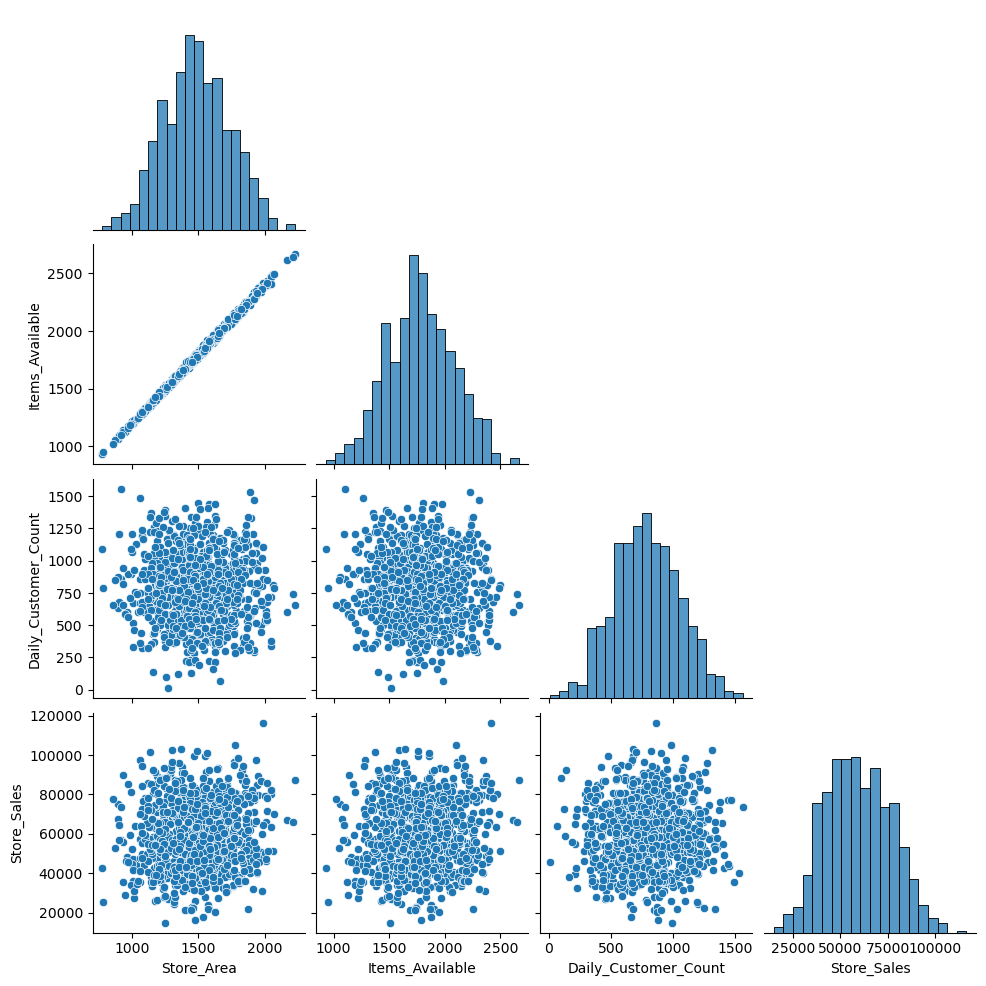

In [13]:
import seaborn as sns

sns.pairplot(df, corner=True);

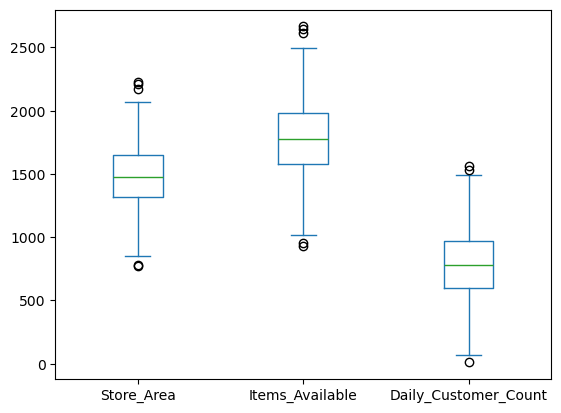

In [14]:
df.drop(columns=['Store_Sales']).plot(kind='box');

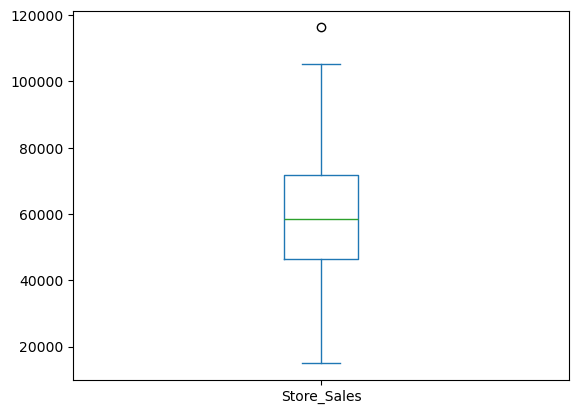

In [15]:
df['Store_Sales'].plot(kind='box');

# Предобработка

## Выбросы

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Store_Sales')
y = df['Store_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train.shape, X_test.shape

((716, 3), (180, 3))

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class RemoveOutliers(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.lefts = {}
        self.rights = {}
        self.medians = None

    def fit(self, X, y=None):
        self.medians = X.median()

        X = X.copy()
        for col in X.columns:
            q3 = np.quantile(X[col], q=0.75)
            q1 = np.quantile(X[col], q=0.25)
            iqr = 1.5 * (q3 - q1)
            self.lefts[col] = q1 - iqr
            self.rights[col] = q3 + iqr
        return self

    def transform(self, X, y=None):
        X = X.copy()

        for col in X.columns:
          X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
        return X

In [18]:
remove_out = RemoveOutliers()

In [19]:
remove_out.fit(X_train)

RemoveOutliers()

In [20]:
remove_out.lefts

{'Store_Area': np.float64(806.0),
 'Items_Available': np.float64(966.875),
 'Daily_Customer_Count': np.float64(16.25)}

In [21]:
remove_out.rights

{'Store_Area': np.float64(2152.0),
 'Items_Available': np.float64(2577.875),
 'Daily_Customer_Count': np.float64(1546.25)}

In [22]:
remove_out.medians

Store_Area              1472.0
Items_Available         1762.5
Daily_Customer_Count     770.0
dtype: float64

In [23]:
X_train_st = remove_out.transform(X_train)
X_test_st = remove_out.transform(X_test)

X_train.shape, X_train_st.shape, y_train.shape

C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]


((716, 3), (716, 3), (716,))

In [24]:
df_train = pd.DataFrame(X_train_st, columns=df.columns[:-1])
df_train.head()

,Store_Area,Items_Available,Daily_Customer_Count
119,1682,2017.0,780
265,1240,1492.0,940
355,1269,1511.0,500
876,1259,1493.0,100
781,1549,1871.0,740


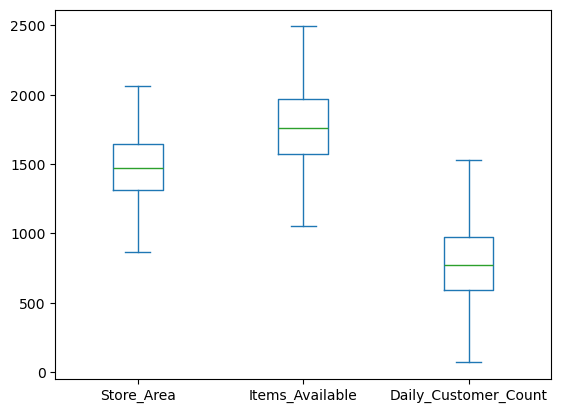

In [25]:
df_train.plot(kind='box');

## Создание новых признаков

### Кластеризация

In [26]:
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


pipe = make_pipeline(
    RemoveOutliers(),
    StandardScaler()
)

pipe

,steps,"[('removeoutliers', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [28]:
pipe.fit(X_train)
X_train_st = pipe.transform(X_train)
X_test_st = pipe.transform(X_test)

X_train_st

C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, pl

array([[ 0.82453474,  0.82235931, -0.01258845],
       [-0.98978108, -0.97506115,  0.58580692],
       [-0.87074226, -0.91001165, -1.05978034],
       ...,
       [-2.42235172, -2.40957386, -0.57358411],
       [ 1.17344163,  1.14075951,  1.55819938],
       [-1.26069702, -1.25237745,  1.10940286]], shape=(716, 3))

In [29]:
df_train = pd.DataFrame(X_train_st, columns=df.columns[:-1])
df_train.head()

,Store_Area,Items_Available,Daily_Customer_Count
0,0.824535,0.822359,-0.012588
1,-0.989781,-0.975061,0.585807
2,-0.870742,-0.910012,-1.059780
3,-0.911790,-0.971637,-2.555769
4,0.278598,0.322505,-0.162187


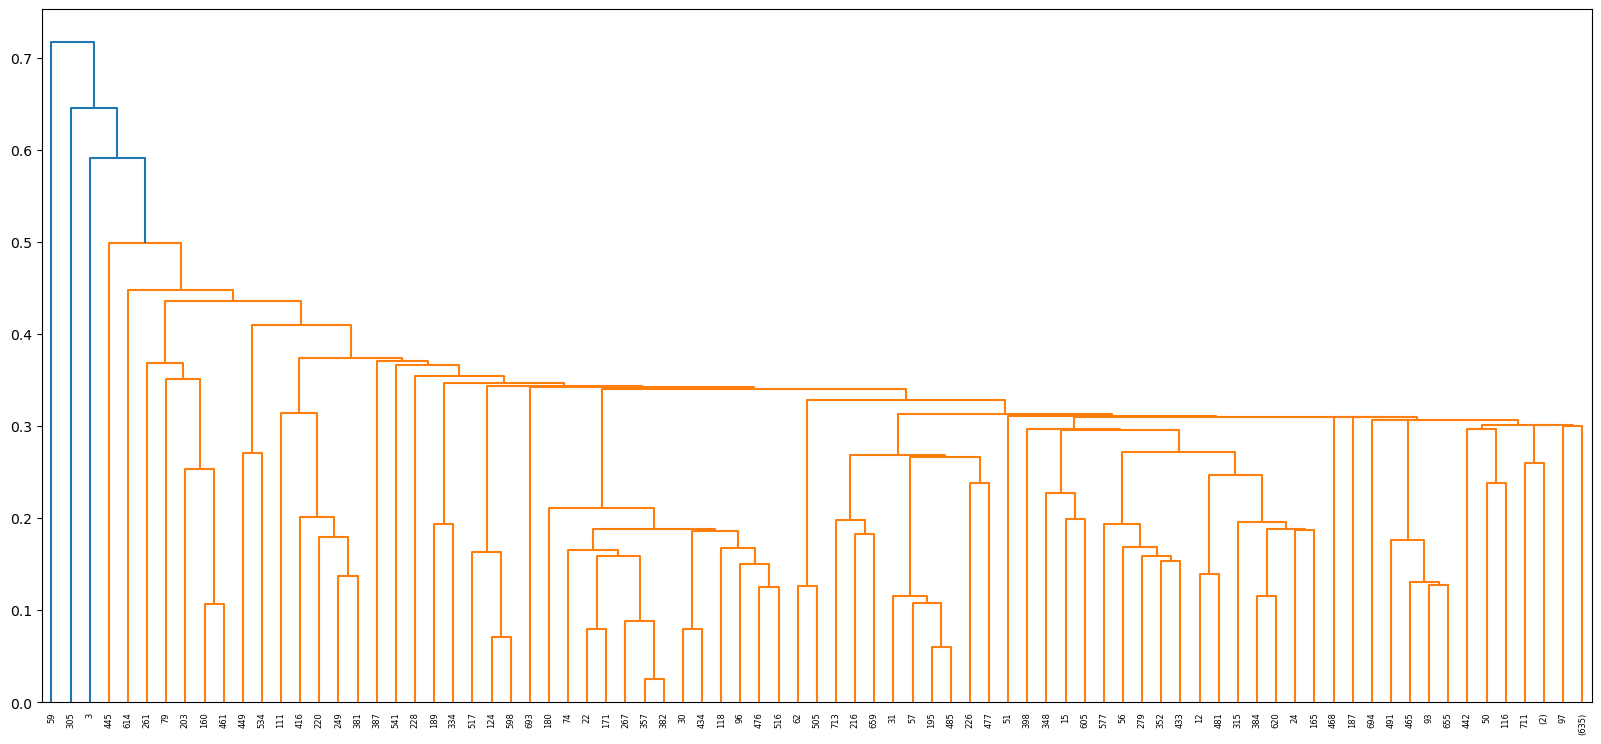

In [30]:
import matplotlib.pyplot as plt

# строим дендрограмму
distance_mat = pdist(df_train) # pdist посчитает нам матрицу попарных расстояний между точками
Z = hierarchy.linkage(distance_mat) # linkage — реализация агломеративного алгоритма

plt.figure(figsize=(20, 9))
dn = hierarchy.dendrogram(Z, truncate_mode='level', p=25)

In [31]:
from sklearn.cluster import KMeans

n_clusters = 6
kmeanModel = KMeans(n_clusters=n_clusters, random_state=1)
kmeanModel.fit(df_train)

pred_labels = kmeanModel.labels_
pred_labels

C:\Users\misha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 0, 2, 2, 1, 4, 2, 0, 2, 4, 2, 0, 5, 3, 0, 5, 0, 2, 2, 2, 0, 5,
       5, 3, 5, 2, 0, 1, 0, 0, 5, 4, 1, 2, 0, 0, 0, 0, 0, 3, 1, 0, 2, 4,
       5, 1, 4, 2, 2, 1, 2, 4, 5, 1, 3, 0, 5, 4, 1, 3, 5, 1, 0, 1, 1, 0,
       0, 0, 1, 4, 3, 1, 1, 1, 5, 5, 2, 0, 2, 4, 0, 0, 0, 3, 4, 2, 4, 0,
       3, 4, 1, 1, 0, 4, 3, 3, 5, 3, 3, 2, 0, 2, 0, 3, 1, 3, 4, 5, 4, 0,
       2, 4, 3, 1, 2, 4, 2, 1, 5, 2, 0, 1, 2, 4, 0, 1, 2, 4, 2, 0, 1, 4,
       2, 0, 0, 5, 4, 2, 0, 2, 0, 1, 2, 1, 4, 4, 3, 1, 2, 1, 0, 0, 5, 1,
       3, 2, 0, 0, 3, 0, 4, 0, 3, 4, 1, 5, 1, 1, 0, 5, 0, 5, 2, 0, 0, 2,
       2, 2, 0, 1, 5, 0, 1, 1, 4, 0, 4, 2, 1, 4, 2, 3, 0, 0, 0, 4, 3, 2,
       3, 0, 1, 4, 5, 4, 1, 0, 5, 3, 0, 2, 0, 4, 2, 4, 2, 1, 4, 4, 2, 4,
       4, 4, 2, 4, 4, 3, 4, 0, 3, 4, 0, 2, 2, 4, 4, 5, 5, 3, 1, 3, 5, 4,
       2, 3, 3, 2, 4, 2, 1, 4, 2, 3, 4, 3, 3, 4, 3, 4, 3, 0, 1, 4, 3, 0,
       4, 1, 0, 5, 3, 4, 1, 3, 1, 3, 2, 4, 2, 4, 4, 5, 2, 3, 0, 3, 5, 0,
       1, 4, 3, 0, 2, 2, 1, 0, 0, 2, 2, 2, 0, 0, 2,

In [32]:
from mpl_toolkits.mplot3d.axes3d import Axes3D


def display_components_in_3D_space(components_df, labels=None):
    components_with_labels_df = pd.concat([components_df, pd.DataFrame(labels)], axis=1)

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')

    if labels is not None:
        ax.scatter(components_with_labels_df.iloc[:, 0],
                   components_with_labels_df.iloc[:, 1],
                   components_with_labels_df.iloc[:, 2],
                   c=components_with_labels_df.iloc[:, -1],
                   cmap=plt.get_cmap('jet'), alpha=0.5)
    else:
        ax.scatter(components_with_labels_df.iloc[:, 0],
                   components_with_labels_df.iloc[:, 1],
                   components_with_labels_df.iloc[:, 2],
                   alpha=0.5)

    ax.set_xlabel('component_1')
    ax.set_ylabel('component_2')
    ax.set_zlabel('component_3')
    plt.title('3D mapping of objects')
    plt.show()

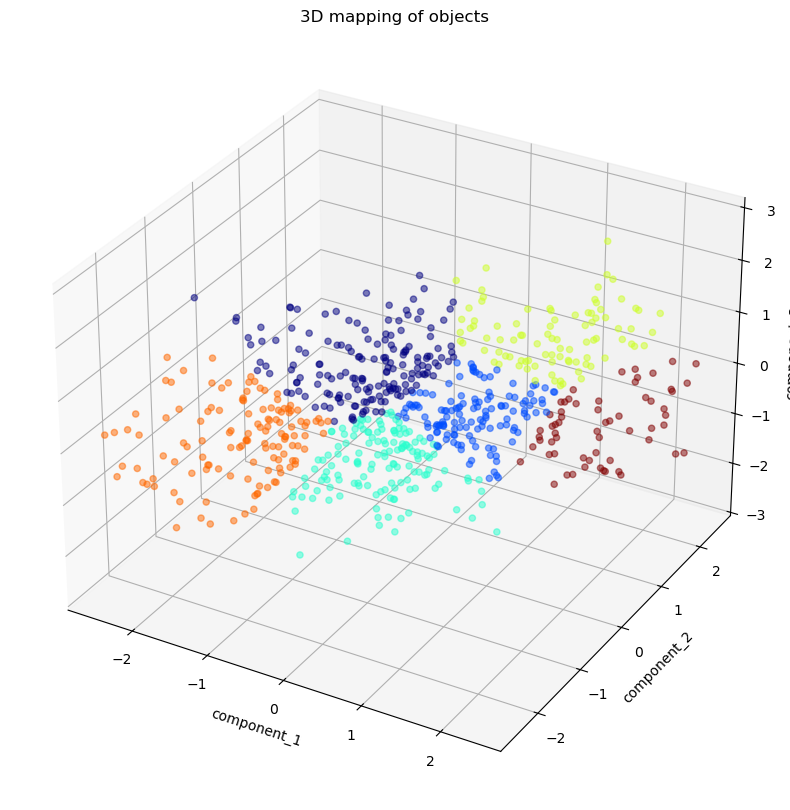

In [33]:
display_components_in_3D_space(df_train, pred_labels)

In [34]:
df_train['cluster1'] = pred_labels
df_train

,Store_Area,Items_Available,Daily_Customer_Count,cluster1
0,0.824535,0.822359,-0.012588,1
1,-0.989781,-0.975061,0.585807,0
2,-0.870742,-0.910012,-1.059780,2
3,-0.911790,-0.971637,-2.555769,2
4,0.278598,0.322505,-0.162187,1
...,...,...,...,...
711,2.088809,2.078842,1.221602,3
712,-1.486460,-1.478339,0.024811,4
713,-2.422352,-2.409574,-0.573584,4
714,1.173442,1.140760,1.558199,3


In [35]:
class Clusters(BaseEstimator, TransformerMixin):
    def __init__(self, columns_name, n_clusters):
        self.scaler = None
        self.kmeanModel = None
        self.columns_name = columns_name
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        X = X.copy()
        self.scaler = StandardScaler().fit(X)
        X = self.scaler.transform(X)

        self.kmeanModel = KMeans(n_clusters=self.n_clusters)
        self.kmeanModel.fit(X)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X = self.scaler.transform(X)

        X = pd.DataFrame(X, columns=self.columns_name)
        labels = self.kmeanModel.predict(X)
        X['cluster'] = labels
        return X

In [36]:
pipeline = make_pipeline(
    RemoveOutliers(),
    StandardScaler(),
    Clusters(columns_name=df.columns[:-1], n_clusters=n_clusters),
)

In [37]:
pipeline.fit(X_train)
X_train_st = pipeline.transform(X_train)
X_test_st = pipeline.transform(X_test)

X_train_st

C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col],

,Store_Area,Items_Available,Daily_Customer_Count,cluster
0,0.824535,0.822359,-0.012588,0
1,-0.989781,-0.975061,0.585807,2
2,-0.870742,-0.910012,-1.059780,5
3,-0.911790,-0.971637,-2.555769,5
4,0.278598,0.322505,-0.162187,1
...,...,...,...,...
711,2.088809,2.078842,1.221602,4
712,-1.486460,-1.478339,0.024811,5
713,-2.422352,-2.409574,-0.573584,5
714,1.173442,1.140760,1.558199,4


In [38]:
df_train = pd.DataFrame(X_train_st, columns=df.columns[:-1].tolist() + ['cluster'])
df_train.head()

,Store_Area,Items_Available,Daily_Customer_Count,cluster
0,0.824535,0.822359,-0.012588,0
1,-0.989781,-0.975061,0.585807,2
2,-0.870742,-0.910012,-1.059780,5
3,-0.911790,-0.971637,-2.555769,5
4,0.278598,0.322505,-0.162187,1


In [39]:
df_test = pd.DataFrame(X_test_st, columns=df.columns[:-1].tolist() + ['cluster'])
df_test.head()

,Store_Area,Items_Available,Daily_Customer_Count,cluster
0,-0.796856,-0.862080,1.558199,2
1,-1.318164,-1.286614,0.436208,2
2,-1.096506,-1.098313,-0.947581,5
3,-1.740957,-1.700877,-0.648384,5
4,-2.574229,-2.597875,-0.461385,5


In [40]:
class FeatureGen(BaseEstimator, TransformerMixin):
    def __init__(self, columns_name):
        self.median_cluster_sales = None
        self.columns_name = columns_name

    def fit(self, X, y=None):
        X = X.copy()
        if not y is None:
            df = pd.concat([X, y], axis=1)
            self.median_cluster_sales = df.groupby('cluster', as_index=False).median()[['cluster', 'Store_Sales']]
            self.median_cluster_sales.rename(columns={'Store_Sales': 'Med_Store_Sales_by_clus'}, inplace=True)

        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['ratio_items/cutomers'] = X['Items_Available'] / X['Daily_Customer_Count']
        X['ratio_size/customers'] = X['Store_Area'] / X['Daily_Customer_Count']
        X['ratio_size/items']     = X['Store_Area'] / X['Items_Available']

        if not self.median_cluster_sales is None:
            X = X.merge(self.median_cluster_sales, on='cluster', how='left')

        X = pd.DataFrame(X, columns=self.columns_name)
        return X

In [41]:
class MyScaler(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.scaler = None

    def fit(self, X, y=None):
        X = X.copy()
        self.scaler = StandardScaler()
        self.scaler.fit(X[self.columns])

        return self.scaler

    def transform(self, X, y=None):
        X = X.copy()
        X[self.columns] = self.scaler.transform(X[self.columns])
        return X

## Финальная предобработка

In [42]:
features = df.columns[:-1].tolist() + ['cluster'] + \
            ['ratio_items/cutomers', 'ratio_size/customers', 'ratio_size/items', 'Med_Store_Sales_by_clus']
features

['Store_Area',
 'Items_Available',
 'Daily_Customer_Count',
 'cluster',
 'ratio_items/cutomers',
 'ratio_size/customers',
 'ratio_size/items',
 'Med_Store_Sales_by_clus']

In [43]:
features_for_scaler = df.columns[:-1].tolist() + \
                ['ratio_items/cutomers', 'ratio_size/customers', 'ratio_size/items', 'Med_Store_Sales_by_clus']

In [44]:
pipeline = make_pipeline(
    RemoveOutliers(),
    Clusters(columns_name=df.columns[:-1], n_clusters=n_clusters),
    FeatureGen(columns_name=features),
    MyScaler(columns=features_for_scaler)
)

In [45]:
pipeline.fit(X_train, y_train)
df_train = pipeline.transform(X_train)
df_test = pipeline.transform(X_test)

df_train

C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1762.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in

,Store_Area,Items_Available,Daily_Customer_Count,cluster,ratio_items/cutomers,ratio_size/customers,ratio_size/items,Med_Store_Sales_by_clus
0,0.824535,0.822359,-0.012588,0,-6.573836,-6.501449,0.046092,1.057001
1,-0.989781,-0.975061,0.585807,2,-0.143054,-0.142709,0.052407,-0.975893
2,-0.870742,-0.910012,-1.059780,4,0.111821,0.107539,0.022866,1.020699
3,-0.911790,-0.971637,-2.555769,4,0.063485,0.061214,0.013513,1.020699
4,0.278598,0.322505,-0.162187,3,-0.175783,-0.145515,-0.024296,0.181223
...,...,...,...,...,...,...,...,...
711,2.088809,2.078842,1.221602,5,0.196982,0.196056,0.047182,0.870955
712,-1.486460,-1.478339,0.024811,2,-5.993699,-5.944537,0.047537,-0.975893
713,-2.422352,-2.409574,-0.573584,2,0.449434,0.446510,0.047440,-0.975893
714,1.173442,1.140760,1.558199,5,0.099035,0.100708,0.059280,0.870955


In [46]:
pipeline.steps[2][1].median_cluster_sales.head()

,cluster,Med_Store_Sales_by_clus
0,0.0,60470.0
1,1.0,54885.0
2,2.0,55990.0
3,3.0,58540.0
4,4.0,60390.0


# Обучение модели

## Дерево решений

<img src='https://venngage-wordpress.s3.amazonaws.com/uploads/2019/08/what-is-a-decision-tree-5.png' width=600>

In [48]:
# 10

#   3       7
# 1  2
#   1 1


# red 2009 56000 - Don't buy
# black 2008 1000 - Don't buy

In [49]:
# (10 + 10 + 15) / 3

In [50]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree = DecisionTreeRegressor(random_state=1,
                             max_depth=2,
                             min_samples_leaf=5
                             )
tree.fit(df_train, y_train)

pred_train = tree.predict(df_train)
pred_test = tree.predict(df_test)

pred_train[:5]

array([59472.59036145, 59472.59036145, 59472.59036145, 59472.59036145,
       59472.59036145])

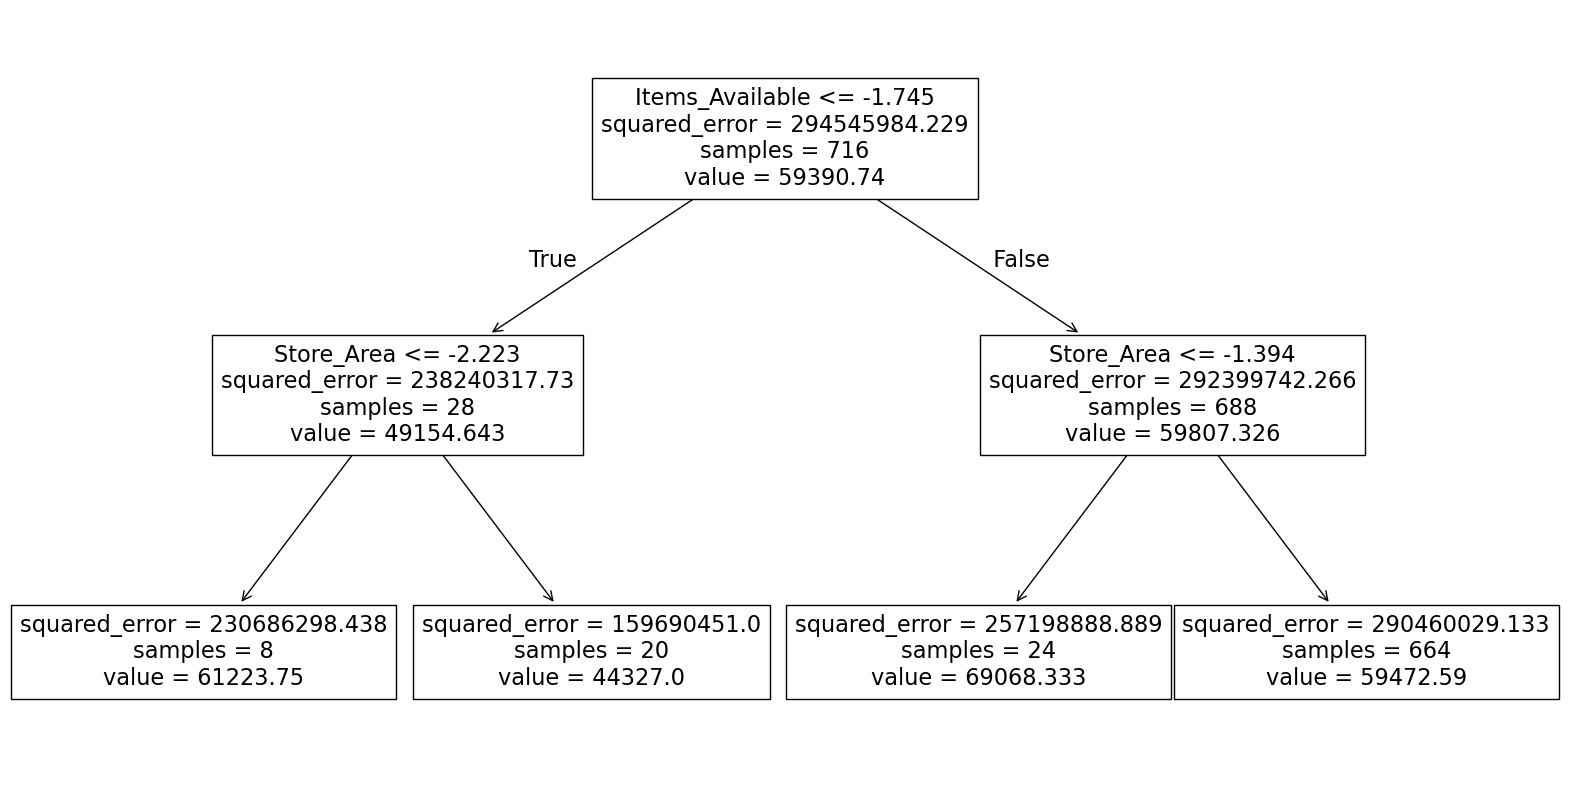

In [53]:
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=features);

In [54]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

rmse 16882.66821781467
rmse 17673.723742390466


In [55]:
# UPD 2025-07-30
# создаем датафрейм с результатами обучения первой модели
stata = pd.DataFrame([{
    'model': 'tree',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata

,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742


## Бэггинг

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Ensemble_Bagging.svg/440px-Ensemble_Bagging.svg.png'>

In [56]:
# [1, 2, 3, 4, 5]

# n = 3
# [2, 3, 2, 1, 2]
# [5, 4, 3, 4, 3]
# [3, 2, 1, 2, 3]

In [57]:
from sklearn.ensemble import BaggingRegressor

# UPD 2025-07-30
# в BaggingRegressor больше нет параметра base_estimator
# bag = BaggingRegressor(base_estimator=DecisionTreeRegressor(),
#                        random_state=1,
#                        n_estimators=200)


# теперь в BaggingRegressor параметр estimator
bag = BaggingRegressor(estimator=DecisionTreeRegressor(),
                       random_state=1,
                       n_estimators=200)

bag.fit(df_train, y_train)

pred_train = bag.predict(df_train)
pred_test = bag.predict(df_test)

pred_train[:5]

array([54451.2 , 63252.7 , 58039.05, 79042.95, 68220.65])

In [59]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

rmse 6648.3191114975125
rmse 18040.794907788157


In [60]:
new_stata = pd.DataFrame([{
    'model': 'bag',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908


## Случайный лес

<img src='https://tikz.net/janosh/random-forest.png' width=700>

In [61]:
# [f1, f2, f3]

# n = 2
# [f1, f2]
# [f2, f3]
# [f1, f2]

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=1, n_estimators=200)
rf.fit(df_train, y_train)

pred_train = rf.predict(df_train)
pred_test = rf.predict(df_test)

pred_train[:5]

array([54755.8 , 63274.8 , 57675.75, 78632.85, 67945.2 ])

In [63]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'rf',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 6667.960640135584
rmse 18027.83780890681


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809


## Воутинг

In [64]:
from sklearn.ensemble import VotingRegressor

vote = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('bag', bag),
        ('tree', tree)
    ]
)
vote.fit(df_train, y_train)

pred_train = vote.predict(df_train)
pred_test = vote.predict(df_test)

pred_train[:5]

array([56226.53012048, 62000.03012048, 58395.79678715, 72382.79678715,
       65212.81345382])

In [65]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'vote',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 9865.451260451315
rmse 17644.16486650797


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809
3,vote,9865.451260,17644.164867


## Стэкинг

In [66]:
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('bag', bag),
        ('tree', tree)
    ],
    final_estimator=RandomForestRegressor(random_state=1)
)
stack.fit(df_train, y_train)

pred_train = stack.predict(df_train)
pred_test = stack.predict(df_test)

pred_train[:5]

array([71988.5, 66238.9, 52050.4, 70030.5, 58529.2])

In [68]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'stack',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 17727.571961666814
rmse 19015.64347947938


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809
3,vote,9865.451260,17644.164867
4,stack,17727.571962,19015.643479
5,stack,17727.571962,19015.643479


## Бустинг
<img src='https://affine.ai/wp-content/uploads/2022/01/144-1.png'>

In [69]:
target_orig = np.array([2, 5, 7, 10, 35])
# dt.fit
pred1 = np.array([0, 3, 10, 12, 37])

error = target_orig - pred1
error

array([ 2,  2, -3, -2, -2])

In [70]:
target = error
# dt2.fit
pred2 = np.array([1, 1, -1, -1, -1])

pred_boosting = pred1 + pred2
pred_boosting

array([ 1,  4,  9, 11, 36])

In [71]:
error = target_orig - pred_boosting
error

array([ 1,  1, -2, -1, -1])

In [72]:
target = error
# dt3.fit
pred3 = np.array([1, 1, -1, -1, -1])

pred_boosting = pred1 + pred2 + pred3
pred_boosting

array([ 2,  5,  8, 10, 35])

In [73]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=1)
gb.fit(df_train, y_train)

pred_train = gb.predict(df_train)
pred_test = gb.predict(df_test)

pred_train[:5]

array([53646.45847911, 56373.06726445, 57158.13566315, 75732.51667575,
       60731.71458912])

In [74]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'boost',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 13608.507762698577
rmse 18441.28658497665


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809
3,vote,9865.451260,17644.164867
4,stack,17727.571962,19015.643479
5,stack,17727.571962,19015.643479
6,boost,13608.507763,18441.286585


# Кросс-валидация


In [77]:
rmses = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    pipeline = make_pipeline(
        RemoveOutliers(),
        Clusters(columns_name=df.columns[:-1], n_clusters=n_clusters),
        FeatureGen(columns_name=features),
        MyScaler(columns=features_for_scaler)
    )

    pipeline.fit(X_train, y_train)
    X_train_st = pipeline.transform(X_train)
    X_test_st = pipeline.transform(X_test)


    model = RandomForestRegressor(random_state=1)
    model.fit(X_train_st, y_train)
    rmses.append(root_mean_squared_error(pred_test, y_test))

rmses

C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1484.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~(X[col].between(self.lefts[col], self.rights[col])), col] = self.medians[col]
C:\Users\misha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
C:\Users\misha\AppData\Local\Temp\ipykernel_14752\3006767455.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in

[18404.1242170773,
 18423.774471766093,
 18334.015080895402,
 19198.50971032937,
 18923.250346182016,
 18178.349674142286,
 18038.735237071545,
 19270.431134767932,
 19681.47944805669,
 18224.864851437625]

In [78]:
# split 1: rmse 17
# split 2: rmse 16
# split 3: rmse 18
# split 4: rmse 16
# split 5: rmse 18


<img src='https://scikit-learn.org/stable/_images/grid_search_cross_validation.png' width=600>


<table>
<tr>
<td>
<img src='https://i.stack.imgur.com/z6lTD.png' width=450>
</td>
<td>
<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_006.png'>
</td>
</tr>
</table>

In [79]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_st, y_train, cv=7, scoring='neg_mean_squared_error')
scores.mean(), scores

(np.float64(-332139597.382768),
 array([-2.80273075e+08, -3.70667347e+08, -3.53675194e+08, -3.01459305e+08,
        -3.59137857e+08, -3.88965785e+08, -2.70798619e+08]))

In [80]:
np.sqrt(np.abs(scores.mean()))

np.float64(18224.697456549668)

In [81]:
np.sqrt(np.abs(scores))

array([16741.35821206, 19252.72310088, 18806.25411997, 17362.5834906 ,
       18950.93286969, 19722.21551074, 16455.95999385])

In [82]:
from sklearn.model_selection import KFold, StratifiedKFold

kf = KFold(n_splits=9, shuffle=True, random_state=1)

scores = cross_val_score(model, X_train_st, y_train, cv=kf, scoring='neg_mean_squared_error')

np.sqrt(np.abs(scores.mean())), np.sqrt(np.abs(scores))

(np.float64(18021.594409632296),
 array([18849.68756794, 16535.24842587, 21677.14154624, 17021.10311425,
        17950.32448238, 18695.11350112, 18386.90730873, 16558.66452349,
        15832.56321028]))

# Поиск лучших параметров

## GridSearch

In [83]:
gb_model = GradientBoostingRegressor(random_state=1,
                                     # min_samples_leaf=10,
                                     # n_estimators=100,
                                     # max_depth=7
                                     )

In [84]:
%%time

from sklearn.model_selection import GridSearchCV


params = {'n_estimators': [50, 100, 200, 400],
          'max_depth': [3, 5, 7, 10],
          'min_samples_leaf': [1, 3, 5, 10]}

gs = GridSearchCV(gb_model, params,
                  scoring='neg_mean_squared_error', # метрика
                  cv=KFold(n_splits=5,   # k (кол-во разбиений/итераций) в кросс-валидации
                           random_state=1,
                           shuffle=True),
                  )
gs.fit(df_train, y_train)

CPU times: total: 1min 46s
Wall time: 1min 55s


,estimator,GradientBoost...andom_state=1)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [85]:
res = pd.DataFrame(gs.cv_results_)
print(res.shape)
res.head()

(64, 16)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.062357,0.002823,0.001411,0.000064,3,1,50,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-3.157896e+08,-3.656440e+08,-3.114550e+08,-3.509756e+08,-2.327630e+08,-3.153254e+08,4.611865e+07,1
1,0.117782,0.003171,0.001518,0.000088,3,1,100,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-3.356953e+08,-3.873688e+08,-3.203403e+08,-3.611712e+08,-2.475275e+08,-3.304206e+08,4.730625e+07,8
2,0.239700,0.003714,0.001830,0.000213,3,1,200,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-3.684062e+08,-4.075016e+08,-3.376219e+08,-3.773942e+08,-2.806701e+08,-3.543188e+08,4.304008e+07,25
3,0.477784,0.026170,0.001914,0.000047,3,1,400,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-4.077116e+08,-4.324383e+08,-3.618689e+08,-4.031729e+08,-3.138805e+08,-3.838144e+08,4.167124e+07,47
4,0.058320,0.000508,0.001348,0.000042,3,3,50,"{'max_depth': 3, 'min_samples_leaf': 3, 'n_est...",-3.242226e+08,-3.738743e+08,-3.095976e+08,-3.494971e+08,-2.275447e+08,-3.169473e+08,4.979950e+07,3


In [86]:
gs.best_params_

{'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 50}

In [87]:
np.sqrt(np.abs(gs.best_score_))

np.float64(17757.405146266017)

**Обучение и оценка модели**

In [88]:
final_model = GradientBoostingRegressor(max_depth=3,
                                        min_samples_leaf=1,
                                        random_state=1,
                                        n_estimators=50)

final_model.fit(df_train, y_train)

pred_train = final_model.predict(df_train)
pred_test = final_model.predict(df_test)

pred_train[:5]

array([56817.30186041, 55927.41244662, 63049.52168859, 52282.78856892,
       60715.32659831])

In [89]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'gs_boost',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 15017.17856179996
rmse 17663.763932669557


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809
3,vote,9865.451260,17644.164867
4,stack,17727.571962,19015.643479
5,stack,17727.571962,19015.643479
6,boost,13608.507763,18441.286585
7,gs_boost,15017.178562,17663.763933


## RandomizedSearchCV

In [90]:
gb_model = GradientBoostingRegressor(random_state=1,
                                    #  min_samples_leaf=10,
                                     # n_estimators=100,
                                     # max_depth=7
                                     )

In [91]:
%%time

from sklearn.model_selection import RandomizedSearchCV


params = {'n_estimators': [50, 100, 200, 400],
          'max_depth': [3, 5, 7, 10],
          'min_samples_leaf': [1, 3, 5, 10]}

rs = RandomizedSearchCV(gb_model, params,
                        n_iter=10,
                        scoring='neg_mean_squared_error', # метрика
                        cv=KFold(n_splits=5,   # k (кол-во разбиений/итераций) в кросс-валидации
                                random_state=1,
                                shuffle=True),
                      )
rs.fit(df_train, y_train)

CPU times: total: 15.1 s
Wall time: 16.8 s


,estimator,GradientBoost...andom_state=1)
,param_distributions,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [92]:
res = pd.DataFrame(rs.cv_results_)
print(res.shape)
res.head()

(10, 16)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_leaf,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.134801,0.019046,0.003372,0.000153,400,3,10,"{'n_estimators': 400, 'min_samples_leaf': 3, '...",-3.909895e+08,-4.499060e+08,-3.485867e+08,-4.112540e+08,-3.440815e+08,-3.889635e+08,3.964757e+07,9
1,0.083541,0.000916,0.001414,0.000024,50,3,5,"{'n_estimators': 50, 'min_samples_leaf': 3, 'm...",-3.336052e+08,-3.950720e+08,-3.277142e+08,-3.463506e+08,-2.476479e+08,-3.300780e+08,4.754319e+07,2
2,0.082708,0.000334,0.001434,0.000039,50,5,5,"{'n_estimators': 50, 'min_samples_leaf': 5, 'm...",-3.389812e+08,-3.991516e+08,-3.054382e+08,-3.547185e+08,-2.442021e+08,-3.284983e+08,5.182065e+07,1
3,0.232003,0.006502,0.001615,0.000030,200,1,3,"{'n_estimators': 200, 'min_samples_leaf': 1, '...",-3.684062e+08,-4.075016e+08,-3.376219e+08,-3.773942e+08,-2.806701e+08,-3.543188e+08,4.304008e+07,5
4,0.354932,0.019228,0.002150,0.000585,200,1,5,"{'n_estimators': 200, 'min_samples_leaf': 1, '...",-3.766044e+08,-4.108737e+08,-3.755151e+08,-3.858417e+08,-3.071517e+08,-3.711973e+08,3.446272e+07,7


In [93]:
rs.best_params_

{'n_estimators': 50, 'min_samples_leaf': 5, 'max_depth': 5}

In [94]:
np.sqrt(np.abs(rs.best_score_))

np.float64(18124.522865173694)

**Обучение и оценка модели**

In [95]:
final_model = GradientBoostingRegressor(max_depth=3,
                                        min_samples_leaf=3,
                                        random_state=1,
                                        n_estimators=50)

final_model.fit(df_train, y_train)

pred_train = final_model.predict(df_train)
pred_test = final_model.predict(df_test)

pred_train[:5]

array([55495.55061487, 56393.16301146, 62901.34207307, 54222.75742217,
       61824.90432992])

In [96]:
rmse_train = root_mean_squared_error(pred_train, y_train)
print('rmse', rmse_train)

rmse_test = root_mean_squared_error(pred_test, y_test)
print('rmse', rmse_test)

new_stata = pd.DataFrame([{
    'model': 'rs_boost',
    'rmse_train': rmse_train,
    'rmse_test': rmse_test
}])

stata = pd.concat([stata, new_stata], ignore_index=True)
stata

rmse 15050.685495599228
rmse 17724.480134148016


,model,rmse_train,rmse_test
0,tree,16882.668218,17673.723742
1,bag,6648.319111,18040.794908
2,rf,6667.960640,18027.837809
3,vote,9865.451260,17644.164867
4,stack,17727.571962,19015.643479
5,stack,17727.571962,19015.643479
6,boost,13608.507763,18441.286585
7,gs_boost,15017.178562,17663.763933
8,rs_boost,15050.685496,17724.480134


In [97]:
stata.sort_values('rmse_test')

,model,rmse_train,rmse_test
3,vote,9865.451260,17644.164867
7,gs_boost,15017.178562,17663.763933
0,tree,16882.668218,17673.723742
8,rs_boost,15050.685496,17724.480134
2,rf,6667.960640,18027.837809
1,bag,6648.319111,18040.794908
6,boost,13608.507763,18441.286585
4,stack,17727.571962,19015.643479
5,stack,17727.571962,19015.643479


# Анализ прогнозов

**Важность признаков**

In [98]:
final_model.feature_importances_

array([0.17805323, 0.13091399, 0.10705075, 0.01086459, 0.17440271,
       0.14746003, 0.24633782, 0.00491689])

In [99]:
feature_importances = pd.DataFrame(zip(df_train.columns,
                                       final_model.feature_importances_),
                                   columns=['feature_name', 'importance'])

feature_importances.sort_values(by='importance', ascending=False, inplace=True)

**Топ-3 фичи**

In [100]:
feature_importances.head(3)

,feature_name,importance
6,ratio_size/items,0.246338
0,Store_Area,0.178053
4,ratio_items/cutomers,0.174403


**Худшие 3 фичи**

In [101]:
feature_importances.tail(3)

,feature_name,importance
2,Daily_Customer_Count,0.107051
3,cluster,0.010865
7,Med_Store_Sales_by_clus,0.004917


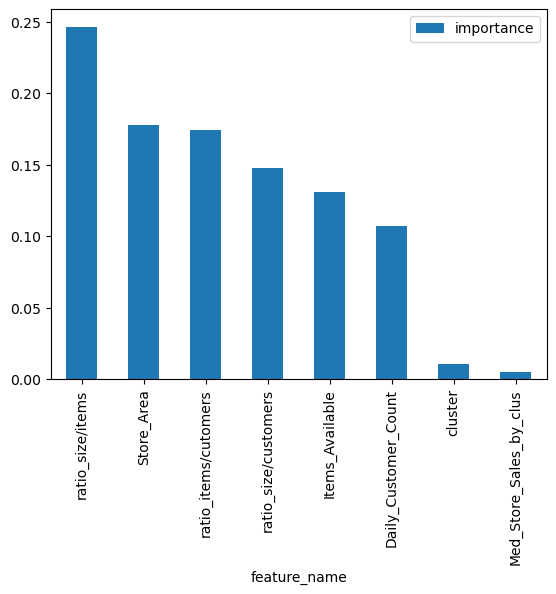

In [102]:
feature_importances.plot(x='feature_name',
                         y='importance',
                         kind='bar');

In [103]:
final_model = GradientBoostingRegressor(max_depth=3,
                                        min_samples_leaf=3,
                                        random_state=1,
                                        n_estimators=50)

final_model.fit(df_train.drop(columns=['cluster']), y_train)

pred_train = final_model.predict(df_train.drop(columns=['cluster']))
pred_test = final_model.predict(df_test.drop(columns=['cluster']))

pred_train[:5]

array([54142.5542296 , 56337.743031  , 63354.78476406, 54905.18261237,
       61161.02156013])

In [104]:
print('rmse', root_mean_squared_error(pred_train, y_train))

rmse 15122.226592022502


In [105]:
print('rmse', root_mean_squared_error(pred_test, y_test))

rmse 17813.55774331727


# Обобщение работы с новой задачей

1. Получить базовое решение

  * Минимально познакомиться с данными
  * Заполнить пропуски простым методом (нулями, медиана, среднее, мода...)
  * Обучить простую модель (линейная, деревья...)
  * Посчитать метрику качества
2. EDA

  * Изучить целевую переменную
      * регрессия - распределение, меры центральной тенденции
      * классификация - баланс классов
  * Изучить признаки
      * корреляция
      * найти проблемные признаки
      * найти пропуски
      * найти выбросы
      * сгенерировать идеи по их заполнению
  * Изучить влияние признаков на целевую переменную
      * корреляция
      * классификация - разделение значений в зависимости от классов
  * Постоянно придумывать идеи для новых признаков (где-то их фиксировать)
3. Предобработка данных

  * Разделить данные на train и test
  * Зависит от выбранной модели
      * Масштабирование
  * Заполнить пропуски
      1. Выкинуть эти данные
      2. Заменять разными методами (медианы, средние значения, бизнес-логика, строить модели...)
      3. Делать/не делать дополнительную фичу
      4. Ничего не делать
  * Обработать выбросы
      1. Выкинуть эти данные
      2. Заменять разными методами (медианы, средние значения, бизнес-логика, строить модели...)
      3. Делать/не делать дополнительную фичу
      4. Ничего не делать
  * Генерация новых признаков
      1. Категориальные признаки
          a. pd.get_dummies, OneHotEncoder
          b. Count/Frequency Encoding
          c. Target Encoding
      2. Вещественные признаки
          a. Feature discretization
          b. Feature binarization
  * Оформить предобработку в класс/функции для воспроизводимости
4. Обучение и валидация моделей

  * Обучить модель на базовых гиперпараметрах
  * Вручную настраивать гиперпарметры
  * Автоматизированный выбор гиперпараметров с кросс-валидацией GridSearchCV/RandomSearchCV
  * Следить за переобучением, если оно появляется, то искать лучший параметр регуляризации
  * Посчитать метрики
5. Воспроизводимость

  * Зафиксировать результаты эксперимента
  * Сохранить модели
  * Сохранить версии библиотек

# Дополнительные материалы

1. Недообучение и переобучение - https://youtu.be/m7P7bnLxIc4
3. Деревья решений - https://habr.com/ru/company/ods/blog/322534/
4. Дерево решений - https://youtu.be/j8L07nuns2Y
5. Как не переобучить дерево решений - https://youtu.be/aWEdaXAZ01M
5. Случайный лес - https://towardsdatascience.com/understanding-random-forest-58381e0602d2
6. Бэггинг и бутстрап + композиции в целом и случайный лес - https://habr.com/ru/company/ods/blog/324402/
6. Бэггинг и случайный лес - https://youtu.be/rawnIo_XtYY
7. Бустинг - https://medium.com/mlreview/gradient-boosting-from-scratch-1e317ae4587d
